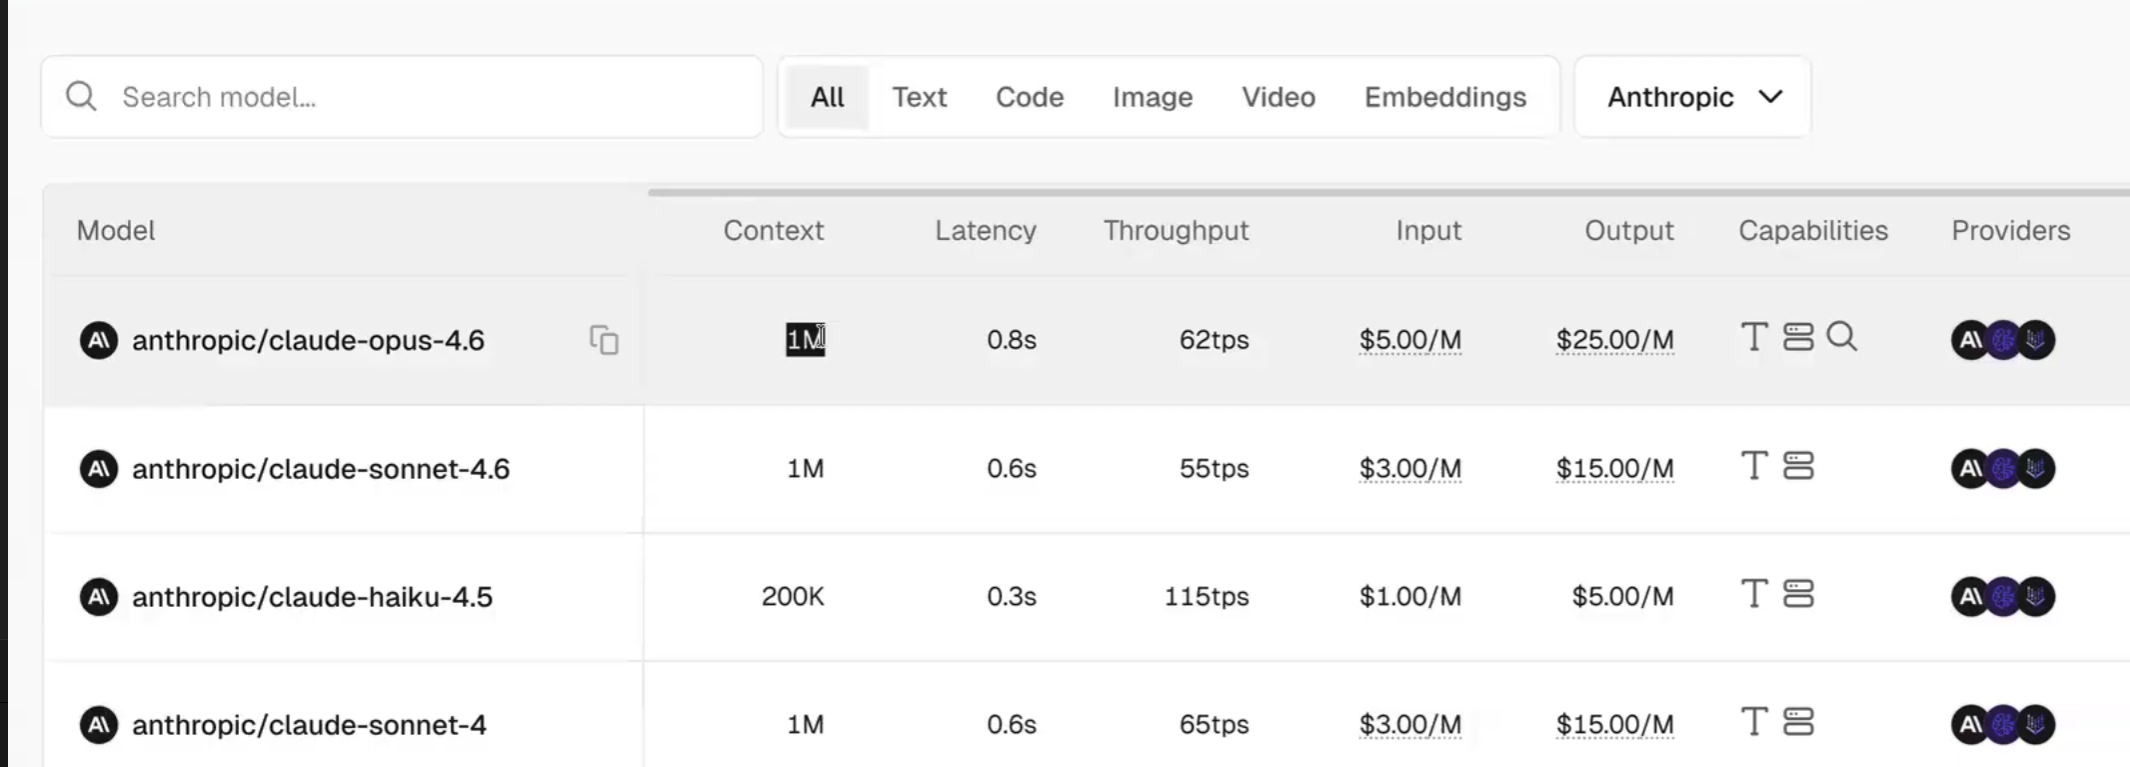

In [ ]:
# Context
- Ngữ cảnh
- Là khả năng mà con AI có thể xử lý được
- VD: `1M` Token Context là khả năng mà con AI có thể xử lý và ghi nhớ được
- Token là đơn vị dữ liệu cơ bản được xử lý bởi các thuật toán, dùng trong các ngôn ngữ tự nhiên LLM
- VD: 1 token = 3 - 4 từ tiếng Anh, 1 - 2 từ Tiếng Việt (vì có dấu và cấu trúc phức tạp)
- Khi chat với AI (Input) -> thì Input cũng tính theo Token

- Bản thân Model sẽ không có trí nhớ của nó, khi chúng ta chat với AI, nó ghi nhớ được nhờ có Ngữ cảnh (Context)

- Khả năng xử lý Model với điều kiện: 
	Input (Nhập câu lệnh chat) + Output (AI trả kết quả) <= Context Window (nằm trong khung)

# Vậy tại sao con AI có thể nhớ được?
- Giả sử con model `anthropic/claude-opus-4.6` có context: `1M Token`/Context Window
- Khi chúng ta chat với con ChatBot bất kỳ, nội dung chat thực tế được tính theo:
	System Prompt (Prompt tả hệ thống) + History [] (Lịch sử chat) + Câu lệnh của user (Message mới nhất)

User: "Chào bạn! Tôi tên là Việt!" => Input thực tế cho con AI:
	System Prompt + [] + "Chào bạn! Tôi tên là Việt!"
AI: "Chào Việt! Mình có thể giúp gì cho Việt"

User: "Vậy tôi tên gì?" => Input thực tế cho AI:
	System Prompt + [
		"Chào bạn! Tôi tên là Việt!" (Input),
		"Chào Việt! Mình có thể giúp gì cho Việt" (Output)
	] + "Vậy tôi tên gì?" (Lúc này Input đã có toàn bộ ngữ cảnh nên sẽ nhớ được)
AI: Tất nhiên rồi, bạn tên Việt, mình có thể giúp gì cho bạn? 

**Vấn đề**: Vì việc nhắc lại cả System Prompt + History cho mỗi lần chat, khi chat càng nhiều, chúng ta đã dần đạt đến giới hạn `1M Token`. tuy nhiên về mặt kỹ thuật AI phải đảm bảo `Input + Output < Context`. Vây khi đạt đến giới hạn (Nếu lớn hơn Context Window) thì lúc này phía ChatBot sẽ phải xử lý:
	1. Reject (Từ chối) request gửi đến => lỗi
	2. Cắt bớt Input , Output đi để đảm bảo vừa vặn với Context => Đây chính là hiện tượng AI càng chat càng bị hay quên
**Giải pháp**: Khi gần đạt đến Context Window, chúng ta sẽ đọc cả cuộc hôi thoại cũ và bảo AI rằng tóm tắt những ý quan trọng thôi. Giả sử Context Window gần đạt `1M Token`, sau khi tóm tắt thì chỉ có `100K Token` thôi. Lúc đó chúng ta sử dụng tóm tắt này (làm History) sang Context mới để sử dụng (Lúc này context đã rộng rãi hơn rất nhiều, chúng ta có thể tiếp tục chat => khả năng quên của AI sẽ bị thấp đi )
- Tuy nhiên từ `1M` mà nén xuống `100K` thì sẽ rơi rớt dữ liệu, càng ngày nó sẽ càng quên.

# Mức độ hiệu quả - Context Rot
- là hiện tượng hiệu suất của LLM bị suy giảm khi lượng thông tin đầu vào quá dài hoặc chứa nhiều dữ liệu dư thừa
- Nếu như không hiểu về Context Rot, chúng ta sẽ bị `hiểu lầm` rằng:
*Cứ model nào có Context càng lớn thì càng ghi nhớ lâu hơn, hiệu quả lâu hơn* --> Chưa chắc
- VD: Model mới nhất `gpt-5.4` có `1M Token`. Nhưng Context Rot lại rất cao. Nghĩa là `gpt-5.4` chỉ cần vượt quá `256k token` là bắt đầu bị Rot, rơi rớt dữ liệu
- Giả sử chúng ta chat với `gpt-5.4` nó sẽ nhớ trong khoảng `256K Token đầu tiên`, nó sẽ nhớ được rất rõ ràng. Nhưng chỉ cần quá con số đó thôi là sẽ thấy hiệu suất suy giảm (mặc dù vẫn nằm trong khoảng `1M context`). Lúc đấy nhiều khi mình hỏi: "Tôi là ai?" có thể nó sẽ khong biết nữa!
- **Lost in the Middle**: Thông tin đầu prompt và cuối prompt nó sẽ có xu hướng là nhớ được, nhưng đoạn prompt ở khúc giữa, mặc dù chúng ta viết vào, nhưng có thể nó sẽ không nhớ, không biết đến sự tồn tại
- Vậy làm sao để test ra được Context Rot:
	- Tạo ra đầu vào prompt gồm rất nhiều từ
	- Tạo ra trò chơi bắt AI ghi nhớ những từ đó
	- Đẩy dần prompt lên rồi hỏi lại AI: Nếu trả lời được thì nó nhớ, còn không trả lời được thì bị Rot
- `gpt-5.4` khi đạt đến 70% Context Window -> là sẽ bị suy giảm chất lượng chỉ còn hơn 30%, có nghĩa gần như là đoán bừa
> Thằng chất lượng nhất hiện nay là `anthropic/claude-opus-4.6` khi đạt đến xấp xỉ 1M Context Window, thì nó vẫn nhớ được đến 75%

# Latency: Độ trễ
- Nếu muốn AI phản hồi nhanh thì phải chọn AI có độ trễ thấp
- Input $5.00/M: Giá tiền - 5 đô cho 1M Token Input
- Output $25.00/M: Giá tiền - 25 đô cho 1M Token Output
- *Mỗi request sẽ tính tiền độc lập*

---


**System prompt**: 
- Định vị được con ChatBot đó là ai, đóng vai trò gì, cách xử lý thế nào, hoạt động ra sao.
- Ví dụ khi chat với con ChatGPT, thì nó ngầm có System prompt, ví dụ: *Bạn là một trợ lý AI cá nhân, bạn là ChatGPT được cung cấp bởi OpenAI, dữ liệu của bạn được training tới..., bạn sẽ hỗ trợ người dùng với văn phong... sau khi trả lời bạn đưa ra gợi ý tiếp theo cho người dùng. Những vấn đề liên quan đến chính trị, tôn giáo nhạy cảm, bạn từ chối trả lời*
- Nói chung **System Prompt** là đoạn văn bản hướng dẫn con AI này nên xử lý thế nào
- VD: Với Momo lại có con ChatBot với **System Prompt** riêng, ví dụ: *Bạn là trợ lý ảo của Momo, bạn hỗ trợ người dùng... không hỗ trợ các vấn đề liên quan đến...*
> **System Prompt** chính là quy trình làm việc, dạy AI phải làm như thế nào